In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score, precision_score, f1_score,\
    confusion_matrix, ConfusionMatrixDisplay, average_precision_score

from catboost import CatBoostClassifier
from catboost import utils

In [2]:
train_part1 = pd.read_parquet("../ClearData/train_part1_with_features.parquet")

In [3]:
x = train_part1.drop(columns="target")
y = train_part1["target"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, stratify=y)   

In [ ]:
def train_models(model, X_train, X_test, y_train, y_test, sample_weight=None):      # This function training model and output accuracy metrics
    if (sample_weight is None):
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train, sample_weight=sample_weight)
        
    predict_train = model.predict(X_train)
    print(f"Train metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Precision: {precision_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Recall: {recall_score(y_true=y_train, y_pred=predict_train)}")
    print(f"F1-score: {f1_score(y_true=y_train, y_pred=predict_train)}")
    y_pred_proba = model.predict_proba(X_train)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_train, y_score=y_pred_proba)}\n")

    predict_test = model.predict(X_test)
    print(f"Test metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Precision: {precision_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Recall: {recall_score(y_true=y_test, y_pred=predict_test)}")
    print(f"F1-score: {f1_score(y_true=y_test, y_pred=predict_test)}")
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_test, y_score=y_pred_proba)}\n")

    print("Confusion matrix")
    cm = confusion_matrix(y_true=y_test, y_pred=predict_test, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)    
    disp.plot()

In [6]:
CatBoost = CatBoostClassifier(iterations=15, depth=2, auto_class_weights='Balanced', verbose=False)

Train metrics:
Accuracy: 0.8753816380601671
Precision: 0.0023259263506514713
Recall: 0.47705483829732837
F1-score: 0.00462928219456754

Test metrics:
Accuracy: 0.8754296157044719
Precision: 0.002197395118583564
Recall: 0.45051783659378597
F1-score: 0.004373458746777856

Confusion matrix


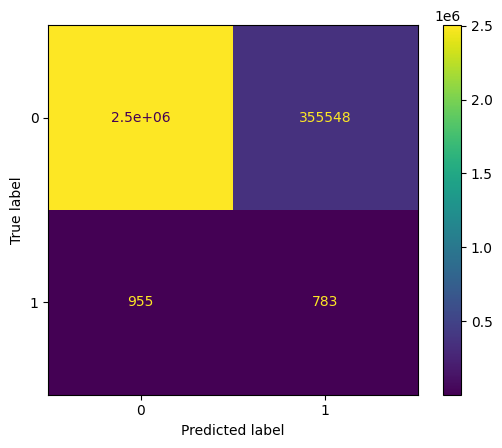

In [7]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [8]:
CatBoost = CatBoostClassifier(iterations=15, depth=3, auto_class_weights='Balanced', verbose=False)

Train metrics:
Accuracy: 0.8665570720262903
Precision: 0.0023244393708245913
Recall: 0.5106736546082066
F1-score: 0.004627814264209388

Test metrics:
Accuracy: 0.8665790779423173
Precision: 0.002223723912496857
Recall: 0.48849252013808975
F1-score: 0.004427293823168983

Confusion matrix


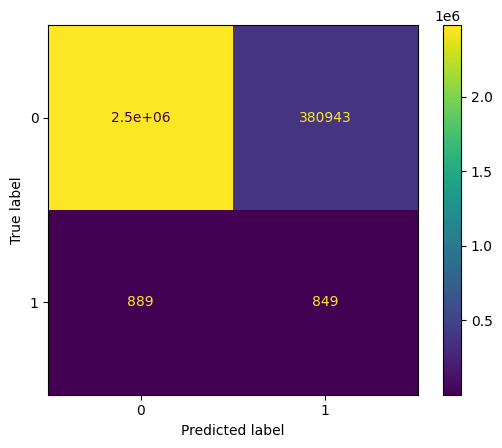

In [9]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [10]:
del CatBoost
gc.collect()

8480

In [11]:
CatBoost2 = CatBoostClassifier(iterations=15, depth=4, auto_class_weights='Balanced', verbose=False)

Train metrics:
Accuracy: 0.8690504005670905
Precision: 0.0023622019232023487
Recall: 0.5092675444202991
F1-score: 0.0047025912056586905

Test metrics:
Accuracy: 0.8688328569531704
Precision: 0.0022194985478670966
Recall: 0.47928653624856155
F1-score: 0.004418535571067875

Confusion matrix


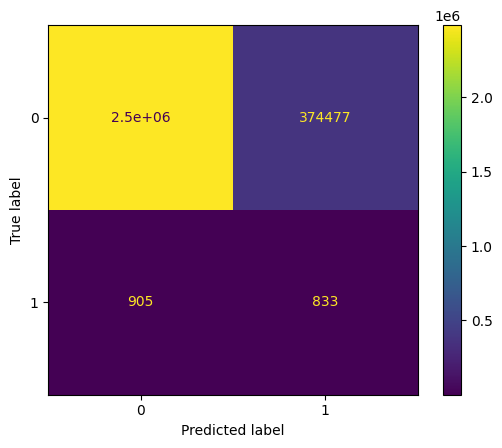

In [12]:
train_models(CatBoost2, X_train, X_test, y_train, y_test)

In [13]:
CatBoost2 = CatBoostClassifier(iterations=50, depth=4, auto_class_weights='Balanced', verbose=False)

Train metrics:
Accuracy: 0.8122026263112396
Precision: 0.0019416565069562252
Recall: 0.6006647066342835
F1-score: 0.0038708006004312743

Test metrics:
Accuracy: 0.8120589406889226
Precision: 0.001862013985546163
Recall: 0.5765247410817032
F1-score: 0.003712039120891334

Confusion matrix


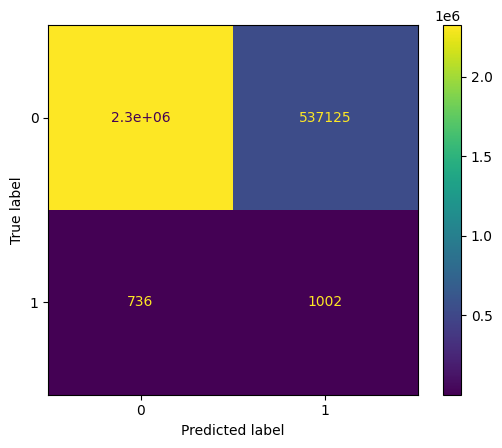

In [14]:
train_models(CatBoost2, X_train, X_test, y_train, y_test)

Попробуем настроить веса меток самостоятельно

In [15]:
weights = {0: 1, 1: 100}
CatBoost2 = CatBoostClassifier(iterations=15, depth=5, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.9977501029439524
Precision: 0.02112293411817976
Recall: 0.059631854787166046
F1-score: 0.03119566671124783

Test metrics:
Accuracy: 0.9976941569468807
Precision: 0.01766223457035126
Recall: 0.051208285385500575
F1-score: 0.02626530913383503

Confusion matrix


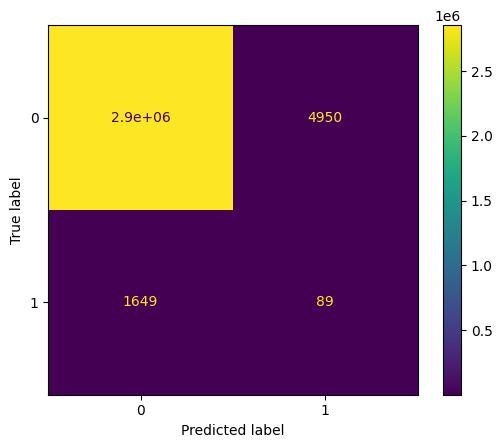

In [16]:
train_models(CatBoost2, X_train, X_test, y_train, y_test)

In [17]:
weights = {0: 1, 1: 100}
CatBoost2 = CatBoostClassifier(iterations=100, depth=5, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.9949749451929736
Precision: 0.01991510763440588
Recall: 0.15083727470279945
F1-score: 0.03518475724753819

Test metrics:
Accuracy: 0.9948683723173042
Precision: 0.016793551276309895
Recall: 0.12945914844649023
F1-score: 0.02973044397463002

Confusion matrix


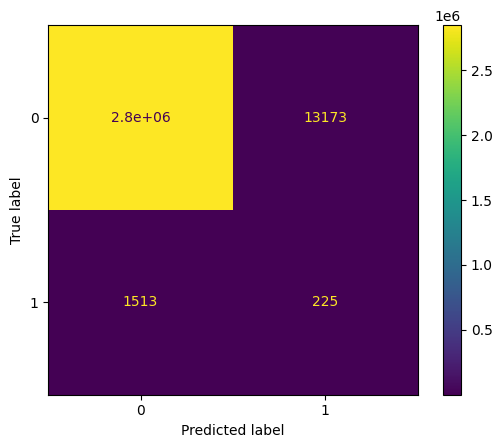

In [18]:
train_models(CatBoost2, X_train, X_test, y_train, y_test)

In [19]:
weights = {0: 1, 1: 1000}
CatBoost2 = CatBoostClassifier(iterations=100, depth=5, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.9277101281552234
Precision: 0.00406140456908014
Recall: 0.4831905918445609
F1-score: 0.00805510287037624

Test metrics:
Accuracy: 0.9275464208591615
Precision: 0.0037314153311450086
Recall: 0.44476409666283084
F1-score: 0.0074007410315082

Confusion matrix


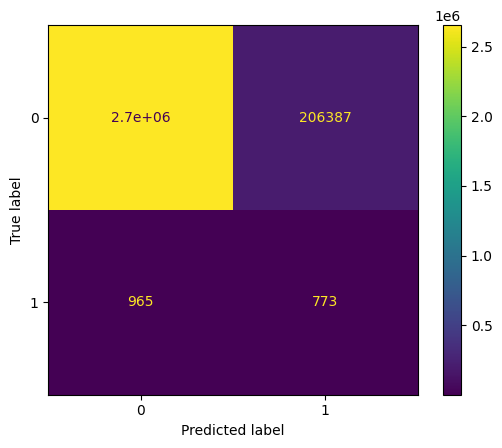

In [20]:
train_models(CatBoost2, X_train, X_test, y_train, y_test)

In [21]:
weights = {0: 1, 1: 1000}
CatBoost2 = CatBoostClassifier(iterations=200, depth=5, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.9272069587704714
Precision: 0.004157654858642401
Recall: 0.4982104052153905
F1-score: 0.008246491274006203

Test metrics:
Accuracy: 0.9269723187018233
Precision: 0.0036925464202414763
Recall: 0.4436133486766398
F1-score: 0.00732412830048875

Confusion matrix


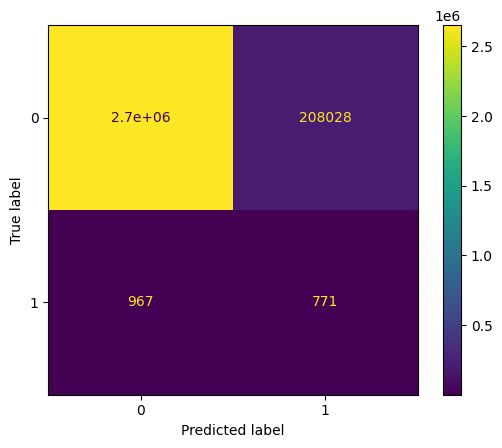

In [22]:
train_models(CatBoost2, X_train, X_test, y_train, y_test)

In [23]:
weights = {0: 1, 1: 1000}
CatBoost2 = CatBoostClassifier(iterations=20, depth=4, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.9193582928643049
Precision: 0.0033263830896571797
Recall: 0.4411990285056884
F1-score: 0.00660298353845499

Test metrics:
Accuracy: 0.9193755110312873
Precision: 0.0032020965488514974
Recall: 0.42462600690448793
F1-score: 0.006356260658363909

Confusion matrix


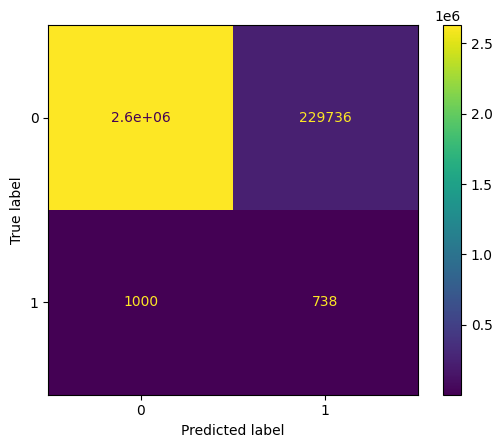

In [24]:
train_models(CatBoost2, X_train, X_test, y_train, y_test)

In [25]:
weights = {0: 1, 1: 800}
CatBoost2 = CatBoostClassifier(iterations=200, depth=4, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.940007921811826
Precision: 0.004699922542271455
Recall: 0.4638246197111083
F1-score: 0.009305552171744306

Test metrics:
Accuracy: 0.9399422054188534
Precision: 0.0042020969687785945
Recall: 0.4148446490218642
F1-score: 0.008319918762513053

Confusion matrix


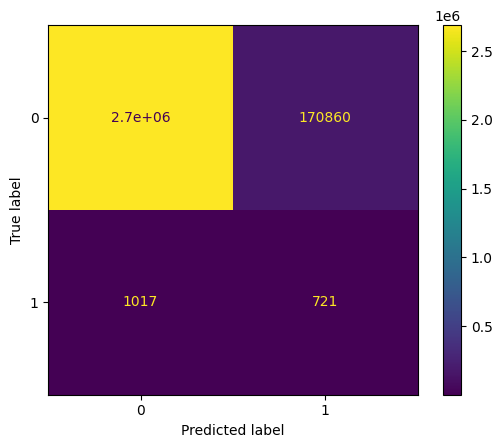

In [26]:
train_models(CatBoost2, X_train, X_test, y_train, y_test)

In [27]:
weights = {0: 1, 1: 500}
CatBoost2 = CatBoostClassifier(iterations=20, depth=4, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.9626632010098796
Precision: 0.00559714362761801
Recall: 0.34226000255656397
F1-score: 0.011014167242570837

Test metrics:
Accuracy: 0.9627050240053672
Precision: 0.005333232824823089
Recall: 0.3256616800920598
F1-score: 0.010494599731145414

Confusion matrix


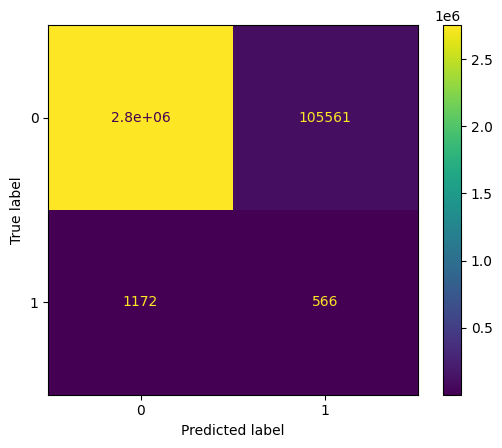

In [28]:
train_models(CatBoost2, X_train, X_test, y_train, y_test)

Из последних показателей могу сделать вывод, что увеличение числа деревьев в ансамбле (после некоторого значения деревьев) сильного эффекта уже не дает, т.е. есть конкретный предел точночти, к которому при постоянном увеличении кол-ва деревьев модель стремится  